# Gradient Descent Based Optimization IV
# More Extensions of Gradient Descent

This article is part of a series, listed below:
- <a href="https://github.com/pw598/Articles/blob/main/Gradient%20Descent%20I%20-%20Derivatives%20and%20Partial%20Derivatives.ipynb">Gradient Descent I - Derivatives and Partial Derivatives</a>
- <a href="https://github.com/pw598/Articles/blob/main/Gradient%20Descent%20II%20-%20Gradient%20Descent.ipynb">Gradient Descent II - Gradient Descent</a>
- <a href="https://github.com/pw598/Articles/blob/main/Gradient%20Descent%20III%20-%20Extensions%20of%20GD.ipynb">Gradient Descent III - Extensions of GD</a>
- <a href="https://github.com/pw598/Articles/blob/main/Gradient%20Descent%20IV%20-%20More%20Extensions%20of%20GD.ipynb">Gradient Descent IV - More Extensions of GD</a>

# Adadelta

<p>Adadelta is an extension of gradient descent that builds upon AdaGrad and RMSProp, and changes the calculation of the custom learning rate so that the units are consistent and no longer require an initial learning rate.</p>

<p>"The idea is derived from AdaGrad in order to improve upon 1) the continual decay of learning rates throughout training, and 2) the need for a manually specified learning rate."</p>
    <ul>
        <li>Adadelta: An Adaptive Learning Rate Method (2012)</li>
    </ul>

<p>"The decaying moving average of the squared partial derivative is calculated for each parameter as with RMSProp. First, the custom learning rate is calculated as the square root of the decaying moving average of the change in the delta divided by the square root of the decaying moving average of the squared partial derivatives."</p>
    <ul>
        <li>Optimization for Machine Learning, Jason Brownlee (2021)</li>
    </ul>

<h4>$\alpha(t+1) = \frac{\sqrt{\delta(1)}+\epsilon}{\sqrt{s(t)}}$</h4>
    <ul>
        <li>$\alpha(t+1)$ is the custom learning rate for a parameter for a given update</li>
        <li>$\epsilon$ is a hyperparameter added to the numerator and denominator to avoid a division by zero</li>
        <li>$\delta(t)$ is the decaying moving average of the squared change to the parameter</li>
        <li>$s(t)$ is the decaying moving average of the squared partial derivatives</li>
    </ul>

<p>Next, the change to the parameter is calculated as the custom learning rate multiplied by the partial derivative.</p>

<p>$\Delta x(t+1) = \alpha(t+1) f'(x(t))$</p>

<p>Next, the decaying average of the squared change to the parameter is updated.</p>

<p>$\delta(t+1) = \delta(t) \rho + \Delta x(t+1)^2 (1-\rho)$</p>
    <ul>
        <li>$\delta(t+1)$ is the decaying average of the change to the variable to be used in the next iteration</li>
        <li>$\Delta x(t+1)$ was calculated in the step before</li>
        <li>$\rho$ is a hyperparameter that acts like momentum</li>
    </ul>

## Code - Adadelta in One Dimension

In [ ]:
# Adapted from Optimization for Machine Learning, Dr. Jason Brownlee
# https://machinelearningmastery.com/optimization-for-machine-learning/

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from math import sqrt
from numpy import meshgrid

In [2]:
def objective(x):
    return x**2 + 4

def d_objective(x):
    return 2*x

In [3]:
def adadelta(objective, derivative, n_iter, rho, ep=1e-3):
    
    solutions = []
    scores = []
    solution = np.array([np.random.rand()*-1 + np.random.rand()])
    
    sq_grad_avg = [0.0]
    sq_para_avg = [0.0]

    for j in range(n_iter):
        gradient = derivative(solution)
        
        for i in range(gradient.shape[0]):
            sg = gradient[i]**2.0
            sq_grad_avg[i] = (sq_grad_avg[i] * rho) + (sg * (1.0-rho))
        new_solution = list()
        
        for i in range(solution.shape[0]):
            alpha = (ep + sqrt(sq_para_avg[i])) / (ep + sqrt(sq_grad_avg[i]))
            change = alpha * gradient[i]
            sq_para_avg[i] = (sq_para_avg[i] * rho) + (change**2.0 * (1.0-rho))
            value = solution[i] - change
            new_solution.append(value)

        solution = np.asarray(new_solution)
        solution_eval = objective(solution)
        solutions.append(solution)
        scores.append(solution_eval)
        print('>%d f(%.5f) = %.5f' % (i, solution, solution_eval))
    return solutions, scores

In [4]:
np.random.seed(7)
n_iter = 30
rho = 0.99

solutions, scores = adadelta(objective, d_objective, n_iter, rho)

>0 f(0.69368) = 4.48119
>0 f(0.67972) = 4.46203
>0 f(0.66435) = 4.44136
>0 f(0.64833) = 4.42033
>0 f(0.63202) = 4.39945
>0 f(0.61563) = 4.37900
>0 f(0.59929) = 4.35915
>0 f(0.58309) = 4.33999
>0 f(0.56708) = 4.32157
>0 f(0.55130) = 4.30394
>0 f(0.53580) = 4.28708
>0 f(0.52059) = 4.27101
>0 f(0.50568) = 4.25571
>0 f(0.49109) = 4.24117
>0 f(0.47683) = 4.22737
>0 f(0.46290) = 4.21427
>0 f(0.44930) = 4.20187
>0 f(0.43603) = 4.19012
>0 f(0.42309) = 4.17901
>0 f(0.41049) = 4.16850
>0 f(0.39821) = 4.15857
>0 f(0.38625) = 4.14919
>0 f(0.37462) = 4.14034
>0 f(0.36330) = 4.13199
>0 f(0.35229) = 4.12411
>0 f(0.34158) = 4.11668
>0 f(0.33117) = 4.10967
>0 f(0.32105) = 4.10307
>0 f(0.31122) = 4.09686
>0 f(0.30166) = 4.09100


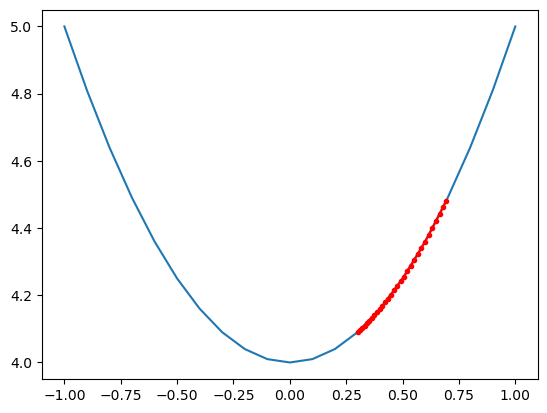

In [5]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

## Code - Adadelta in Two Dimensions

In [6]:
def objective_2d(x, y): 
    return 2*x**2.0 + 4*y**2.0

def d_objective_2d(x, y):
    return np.asarray([2*x, 2*y])

In [7]:
def adadelta_2d(objective, derivative, n_iter, rho, ep=1e-3):
    
    solutions = []
    solution = np.random.rand(2)*-1 + np.random.rand(2)
    
    sq_grad_avg = [0.0 for _ in range(len(solution))]
    sq_para_avg = [0.0 for _ in range(len(solution))]

    for j in range(n_iter):
        gradient = derivative(solution[0], solution[1])
        
        for i in range(gradient.shape[0]):
            sg = gradient[i]**2.0
            sq_grad_avg[i] = (sq_grad_avg[i] * rho) + (sg * (1.0-rho))
        new_solution = list()
        
        for i in range(solution.shape[0]):
            alpha = (ep + sqrt(sq_para_avg[i])) / (ep + sqrt(sq_grad_avg[i]))
            change = alpha * gradient[i]
            sq_para_avg[i] = (sq_para_avg[i] * rho) + (change**2.0 * (1.0-rho))
            value = solution[i] - change
            new_solution.append(value)

        solution = np.asarray(new_solution)
        solutions.append(solution)
        solution_eval = objective(solution[0], solution[1])
        print('>%d f(%s) = %.5f' % (j, solution, solution_eval))
    return solutions

In [8]:
# np.random.seed(7)
# n_iter = 30
# rho = 0.99

solutions = adadelta_2d(objective_2d, d_objective_2d, n_iter, rho)

>0 f([ 0.52967209 -0.17523251]) = 0.68393
>1 f([ 0.51578236 -0.1618854 ]) = 0.63689
>2 f([ 0.50055352 -0.1478346 ]) = 0.58853
>3 f([ 0.48477555 -0.13402437]) = 0.54186
>4 f([ 0.46882373 -0.12088802]) = 0.49805
>5 f([ 0.45291052 -0.10863176]) = 0.45746
>6 f([ 0.4371678  -0.09734095]) = 0.42013
>7 f([ 0.42168185 -0.08703165]) = 0.38593
>8 f([ 0.40651065 -0.07767944]) = 0.35464
>9 f([ 0.39169353 -0.06923663]) = 0.32602
>10 f([ 0.37725692 -0.06164308]) = 0.29985
>11 f([ 0.36321805 -0.054833  ]) = 0.27588
>12 f([ 0.34958738 -0.04873936]) = 0.25392
>13 f([ 0.33637031 -0.04329654]) = 0.23379
>14 f([ 0.32356842 -0.03844196]) = 0.21530
>15 f([ 0.31118034 -0.03411704]) = 0.19832
>16 f([ 0.29920246 -0.03026757]) = 0.18271
>17 f([ 0.28762939 -0.0268439 ]) = 0.16834
>18 f([ 0.27645443 -0.02380086]) = 0.15512
>19 f([ 0.26566983 -0.02109754]) = 0.14294
>20 f([ 0.25526706 -0.01869708]) = 0.13172
>21 f([ 0.24523701 -0.01656635]) = 0.12138
>22 f([ 0.23557015 -0.01467567]) = 0.11185
>23 f([ 0.22625665 -0

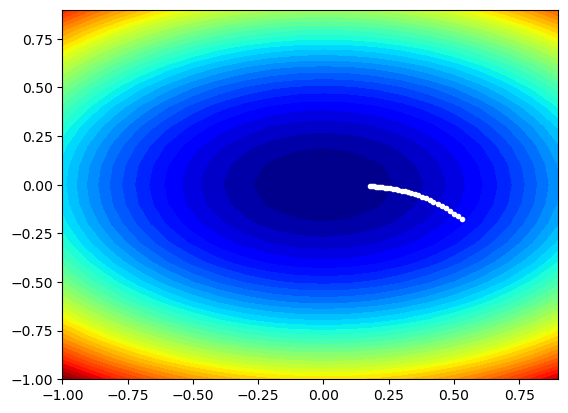

In [9]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

# Adam

<p>Adagrad and RMSProp use a separate learning rate for each input variable but may result in a learning rate that rapidly decreases to small values. Adam, short for Adaptive Movement Estimator, adapts a learning rate for each input variable of the objective function, and further smoothes the search process by using an exponentially decreasing moving average of the gradient.</p>

<p>The method computes individual adaptive learning rates for different parameters from estimates of first and second moments of the gradients. This involves maintaining an exponentially decaying mean gradient (first moment) and variance (second moment) for each input variable.</p>

<p>A moment vector $m$ and infinity norm (largest magnitude among each element of a vector) $\nu$ is maintained for each parameter being optimized, and initialized to zero at the start of the search.</p>

<p>If we focus on one parameter, which then generalizes to vector operations updating all parameters, the gradient is first calculated for the current time step.</p>

<p>$g(t) = f'(x(t-1))$</p>

<p>Next, the first moment is updated using the gradient and a hyperparameter $\beta_1$.</p>

<p>$m(t) = \beta_1 \times m(t-1) + (1-\beta_1) \times g(t)$</p>

<p>Then the second moment is updated using the squared gradient and a hyperparameter $\beta_2$.</p>

<p>$\nu(t) = \beta_2 \times \nu(t-1) + (1-\beta) \times g(t)^2$</p>

<p>Next, the first and second moments are bias-corrected, starting with the first moment.</p>

<h4>$\hat{m}(t) = \frac{m(t)}{1-\beta_1(t)}$</h4>

<p>And then the second moment:</p>

<h4>$\nu(t) = \frac{\nu(t)}{1-\beta_2(t)}$</h4>

<p>The $\beta_1$ and $\beta_2$ hyperparameters are decayed on a schedule over the iterations of the algorithm.</p>

<p>Finally, we calculate the value for the parameter for this iteration, where $\alpha$ is a hyperparameter.</p>

<h4>$\alpha(t) = \alpha \frac{\sqrt{1-\beta_2(t)}}{1-\beta_1(t)}$</h4>
<h4>$x(t) = x(t-1) - \frac{\alpha(t) m(t)}{\sqrt{\nu(t)} + \epsilon}$</h4>
    <ul>
        <li>$\alpha$ is the initial step size, typically around $0.001$</li>
        <li>$\beta_1$ is the decay factor for the first momentum, typically $0.9$</li>
        <li>$\beta_2$ is the decay factor for the infinity norm, typically around $0.999$</li>
    </ul>

## Code - Adam in One Dimension

In [10]:
def adam(objective, derivative, n_iter, alpha, beta1, beta2, eps=1e-8):
    
    solutions = []
    scores = []

    x = np.array([np.random.rand()*-1 + np.random.rand()])
    score = objective(x)

    m = [0.0]
    v = [0.0]

    for t in range(n_iter):
        g = derivative(x)

        for i in range(len(x)):
            
            # m(t) = beta1 * m(t-1) + (1 - beta1) * g(t)
            m[i] = beta1 * m[i] + (1.0 - beta1) * g[i]
            
            # v(t) = beta2 * v(t-1) + (1 - beta2) * g(t)^2
            v[i] = beta2 * v[i] + (1.0 - beta2) * g[i]**2
            
            # mhat(t) = m(t) / (1 - beta1(t))
            mhat = m[i] / (1.0 - beta1**(t+1))
            
            # vhat(t) = v(t) / (1 - beta2(t))
            vhat = v[i] / (1.0 - beta2**(t+1))
            
            # x(t) = x(t-1) - alpha * mhat(t) / (sqrt(vhat(t)) + ep)
            x[i] = x[i] - alpha * mhat / (sqrt(vhat) + eps)
            
        score = objective(x)
        scores.append(score)
        solutions.append(x.copy())
        print('>%d f(%s) = %.5f' % (t, x, score))
    return solutions, scores

In [11]:
np.random.seed(7)
n_iter = 30
alpha = 0.02
beta1 = 0.8
beta2 = 0.999

solutions, scores = adam(objective, d_objective, n_iter, alpha, beta1, beta2)

>0 f([0.6836105]) = 4.46732
>1 f([0.66364447]) = 4.44042
>2 f([0.64373601]) = 4.41440
>3 f([0.62390913]) = 4.38926
>4 f([0.60418803]) = 4.36504
>5 f([0.58459689]) = 4.34175
>6 f([0.56515959]) = 4.31941
>7 f([0.54589954]) = 4.29801
>8 f([0.52683951]) = 4.27756
>9 f([0.50800143]) = 4.25807
>10 f([0.48940631]) = 4.23952
>11 f([0.47107405]) = 4.22191
>12 f([0.45302346]) = 4.20523
>13 f([0.4352721]) = 4.18946
>14 f([0.41783632]) = 4.17459
>15 f([0.40073119]) = 4.16059
>16 f([0.38397051]) = 4.14743
>17 f([0.36756684]) = 4.13511
>18 f([0.35153148]) = 4.12357
>19 f([0.33587449]) = 4.11281
>20 f([0.32060475]) = 4.10279
>21 f([0.30573]) = 4.09347
>22 f([0.29125681]) = 4.08483
>23 f([0.27719069]) = 4.07683
>24 f([0.26353606]) = 4.06945
>25 f([0.25029632]) = 4.06265
>26 f([0.23747389]) = 4.05639
>27 f([0.22507023]) = 4.05066
>28 f([0.21308584]) = 4.04541
>29 f([0.20152035]) = 4.04061


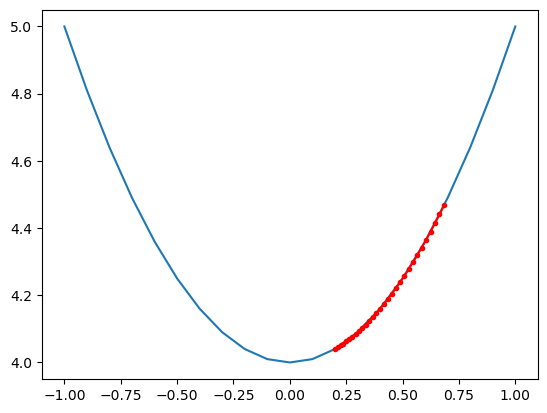

In [12]:
x = np.arange(-1, 1.1, 0.1)
results = objective(x)

plt.plot(x, results)
plt.plot(solutions, scores, '.-', color='red')
plt.show()

It fails to reach the bottom of this function in as many steps as the previous extensions of gradient descent, but can outperform simpler methods when the gradient is more complicated.

# Adam Optimization in Two Dimensions

In [13]:
def adam_2d(objective, derivative, n_iter, alpha, beta1, beta2, eps=1e-8):
    
    solutions = []
    x = np.random.rand(2)*-1 + np.random.rand(2)
    score = objective(x[0], x[1])

    m = [0.0 for _ in range(len(x))]
    v = [0.0 for _ in range(len(x))]

    for t in range(n_iter):
        g = derivative(x[0], x[1])

        for i in range(x.shape[0]):
            
            # m(t) = beta1 * m(t-1) + (1 - beta1) * g(t)
            m[i] = beta1 * m[i] + (1.0 - beta1) * g[i]
            
            # v(t) = beta2 * v(t-1) + (1 - beta2) * g(t)^2
            v[i] = beta2 * v[i] + (1.0 - beta2) * g[i]**2
            
            # mhat(t) = m(t) / (1 - beta1(t))
            mhat = m[i] / (1.0 - beta1**(t+1))
            
            # vhat(t) = v(t) / (1 - beta2(t))
            vhat = v[i] / (1.0 - beta2**(t+1))
            
            # x(t) = x(t-1) - alpha * mhat(t) / (sqrt(vhat(t)) + ep)
            x[i] = x[i] - alpha * mhat / (sqrt(vhat) + eps)
            
        score = objective_2d(x[0], x[1])
        solutions.append(x.copy())
        print('>%d f(%s) = %.5f' % (t, x, score))
    return solutions

In [14]:
# np.random.seed(7)
# n_iter = 30
# alpha = 0.02
# beta1 = 0.8
# beta2 = 0.999

solutions = adam_2d(objective_2d, d_objective_2d, n_iter, alpha, beta1, beta2)

>0 f([ 0.51958028 -0.16496931]) = 0.64879
>1 f([ 0.49962561 -0.14512813]) = 0.58350
>2 f([ 0.47974834 -0.12557745]) = 0.52340
>3 f([ 0.45998156 -0.10646969]) = 0.46851
>4 f([ 0.44035906 -0.08797779]) = 0.41879
>5 f([ 0.42091499 -0.07029321]) = 0.37410
>6 f([ 0.40168356 -0.05362128]) = 0.33420
>7 f([ 0.3826987  -0.03817324]) = 0.29875
>8 f([ 0.36399376 -0.02415479]) = 0.26732
>9 f([ 0.34560118 -0.01175163]) = 0.23943
>10 f([ 0.32755231 -0.00111363]) = 0.21459
>11 f([0.30987708 0.00765987]) = 0.19228
>12 f([0.29260386 0.01453099]) = 0.17208
>13 f([0.27575922 0.01952826]) = 0.15361
>14 f([0.2593678  0.02274488]) = 0.13661
>15 f([0.24345217 0.02433124]) = 0.12091
>16 f([0.2280327  0.02448329]) = 0.10640
>17 f([0.21312749 0.02342909]) = 0.09304
>18 f([0.19875229 0.02141515]) = 0.08084
>19 f([0.18492045 0.01869372]) = 0.06979
>20 f([0.17164287 0.0155115 ]) = 0.05988
>21 f([0.158928   0.01210007]) = 0.05110
>22 f([0.14678186 0.00866783]) = 0.04339
>23 f([0.13520801 0.00539372]) = 0.03668
>24 

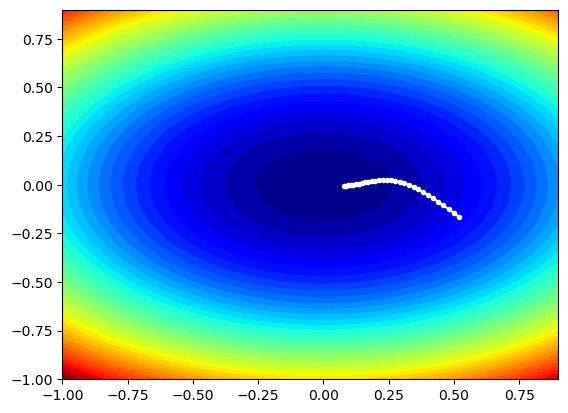

In [15]:
xaxis = np.arange(-1, 1, 0.1)
yaxis = np.arange(-1, 1, 0.1)
x, y = meshgrid(xaxis, yaxis)

results = objective_2d(x, y)
plt.contourf(x, y, results, levels=50, cmap='jet')
solutions = np.asarray(solutions)
plt.plot(solutions[:, 0], solutions[:, 1], '.-', color='w')
plt.show()

# References

- Zeiler, M. D. (2012). Adam: A Method for Stochastic Optimization. ArXiv. 
https://doi.org/arXiv:1412.6980

- Brownlee, J. (2021). Optimization for Machine Learning (A. Tam, Ed.) (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/optimization-for-machine-learning/

- Cristina, S., Saeed, M., & Tam, A. (2022). Calculus for Machine Learning (1st ed.). MachineLearningMastery. https://machinelearningmastery.com/calculus-for-machine-learning/

- Cohen, M. X. (2024). Master calculus 1 using Python: Derivatives and applications [Online Video]. Udemy. https://www.udemy.com/course/pycalc1_x

- Cohen, M. X. (2024). A deep understanding of deep learning [Online Video]. Udemy. https://www.udemy.com/course/deeplearning_x

- Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press. 
https://www.deeplearningbook.org/